**Overview**  

This notebook is inteded to visualize molecules, which are poorly predicted with SVR algorithm and PaDEL descriptors. As we saw, there were some molecules in test dataset on previous step, that were far away from diagonal line. Here we visualize these molecules from the whole dataset

In [92]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from rdkit.Chem import MolFromSmiles
import mols2grid

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

We read file with targets and SMILES to use it in visualization

In [84]:
mol_df = pd.read_csv('targets_with_SMILES_curated.csv', usecols = [1,2,3])

Let's load descriptors and targets

In [12]:
with open('X_padel_dropped.pickle', 'rb') as inp:
    X = pickle.load(inp)

In [14]:
with open('EACN.pickle', 'rb') as inp:
    y = pickle.load(inp)

Let's train a pipe with optimal hyperparameters

In [15]:
pipe = make_pipeline(StandardScaler(), SVR(C = 7.008474598564191,
                                           coef0 = 0.5325084098836236,
                                           degree = 2,
                                           gamma = 'scale',
                                           kernel = 'poly'))

Then we predict values of targets using cross-validatin. This technique splites the whole datasets into several folds (10 in this case). One of them is used as a test set, the other ones are used as training set. Values, obtained when predicting in test set are filled into *y_predicted* array. Then the next fold becomes a test set, pipe is re-trained and procedure is repeated until all y values are predicted 

In [16]:
y_predicted = cross_val_predict(pipe, X, y, cv = 10)

Then we plot true values vs predicted values

CV R2 score is 0.8285337746382707
CV RMSE is 2.6275788773428155
CV MAE is 1.5697238231961628


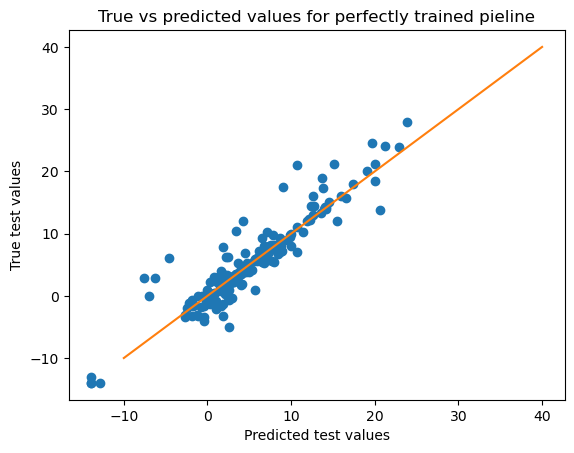

In [25]:
plt.plot(y_predicted, y, 'o')
plt.plot([-10,40], [-10,40])
plt.title('True vs predicted values for perfectly trained pieline')
plt.ylabel('True test values')
plt.xlabel('Predicted test values')

print('CV R2 score is {}'.format(r2_score(y_predicted, y)))
print('CV RMSE is {}'.format(root_mean_squared_error(y_predicted, y)))
print('CV MAE is {}'.format(mean_absolute_error(y_predicted, y)))

And we visualize moleules which have an error hgher then RMSE. There are 34 of them, which is 18% of the whole dataset

In [119]:
is_outlier = (np.abs(y_predicted - y) > 2.63).to_list()
mol_df['predicted_EACN'] = y_predicted
mol_df['Is_outlier'] = is_outlier
mol_df['mol'] = mol_df['SMILES'].apply(lambda x: MolFromSmiles(x))

In [120]:
mols2grid.display(mol_df.query('Is_outlier==True'), subset = ['Name', 'EACN', 'predicted_EACN'] )

MolGridWidget()